In [1]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_timemax_noise import LogLike
# from loglike_phasemax_noise import LogLike
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 3/12
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 4.5
qS = np.pi
phiS = 0.
qK = 0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    seed=42,
    verbose=False,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

data_snr = float(gwf.rhostat_timemax(loglike_obj.signal).get())
print(f'SNR (time-max): {data_snr:.4f}')

print("Setting up log_density and prior functions...")

def log_density(params):
    params = np.asarray(params)
    log_likes = np.zeros(params.shape[0])
    for i in range(params.shape[0]):
        logm1, logm2, a, p0, e0 = params[i]
        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a, p0, e0,
                xI0, dist, qS, phiS, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0
            ])) 
        except Exception:
            loglike = -np.inf
        log_likes[i] = loglike
    return log_likes


def prior_transform(u):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.6, 6.4]
    logm2lim = [0.8, 1.3]
    alim = [0.3, 0.99]
    p0lim = [8.0, 11.0]
    e0lim = [0.2, 0.5]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    return u


Using dt=5s, T=0.25yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
LogLike initialized.
SNR (time-max): 10.9862
Setting up log_density and prior functions...


In [ ]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paris2/int_TDI'


In [3]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl')

In [4]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

In [5]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.43681698, 0.16958808, 0.54010462, 0.42453708, 0.91413517],
        [1.07770573, 0.51598698, 0.17046237, 0.41453449, 0.8271428 ],
        [0.89570762, 0.28648435, 0.35095973, 0.3612681 , 0.94745904],
        ...,
        [0.50701775, 0.39978259, 0.59915881, 0.30764124, 0.66455995],
        [0.50314141, 0.40051134, 0.58801087, 0.32218443, 0.66503447],
        [0.49247073, 0.38905023, 0.56468274, 0.35315998, 0.67926746]])]

In [6]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([ 111.47785003,          -inf,    5.1711691 , ..., 1021.73330679,
        1053.34517783,  977.49134722])]

In [7]:
sampler.now_covariances

[array([[ 4.59703034e-05,  3.21521235e-05,  1.10241452e-04,
         -1.45246637e-04, -4.48423712e-05],
        [ 3.21521235e-05,  3.32835634e-05,  7.13464243e-05,
         -9.41724695e-05, -4.18680023e-05],
        [ 1.10241452e-04,  7.13464243e-05,  2.67460209e-04,
         -3.52284244e-04, -1.01929260e-04],
        [-1.45246637e-04, -9.41724695e-05, -3.52284244e-04,
          4.64034339e-04,  1.34472521e-04],
        [-4.48423712e-05, -4.18680023e-05, -1.01929260e-04,
          1.34472521e-04,  5.39756685e-05]])]

In [8]:
np.argmax(logden_list)

61933

In [9]:
maxld_pt1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
maxld_pt1

array([[6.00926884, 1.00425196, 0.71923825, 8.89034851, 0.39650127]])

In [10]:
log_density(maxld_pt1)

array([10.92697646])

In [11]:
log_density([param_true])

array([10.91236408])

In [12]:
param_ranges = [(5.6,6.4),
                (0.8,1.3),
                (0.3,0.99),
                (8.0,11.0),
                (0.2,0.5),
                ]
param_ranges

[(5.6, 6.4), (0.8, 1.3), (0.3, 0.99), (8.0, 11.0), (0.2, 0.5)]

In [13]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]
param_true

[6.0, 1.0, 0.7, 9, 0.4]

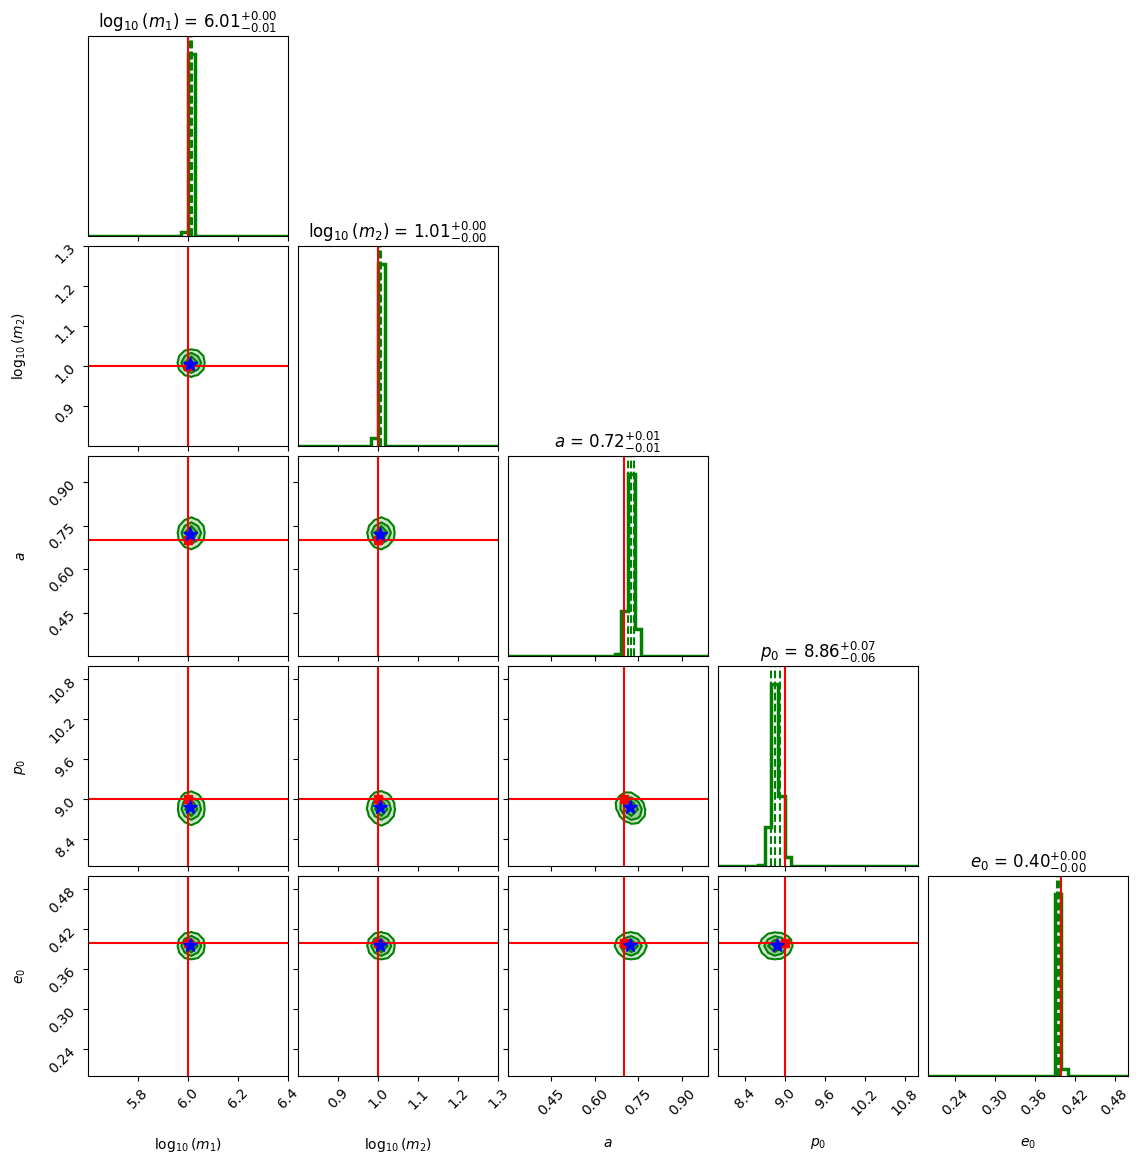

In [14]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$T$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)




In [15]:
w_norm = weights / weights.sum()
ess = 1.0 / np.sum(w_norm**2)
print(f"ESS: {ess:.1f}  ({100*ess/len(weights):.2f}% of N={len(weights)})")

ESS: 31.7  (0.03% of N=100000)


# connection plot

In [16]:
proc1_maxld_pt = maxld_pt1.copy()
proc1_maxld_pt

array([[6.00926884, 1.00425196, 0.71923825, 8.89034851, 0.39650127]])

In [17]:
from scipy.stats import chi2

# --- Mahalanobis distance: does this run's posterior ellipsoid contain the truth? ---
w_norm_mh = weights / weights.sum()

rng_mh = np.random.default_rng(0)
idx_mh = rng_mh.choice(len(samples), size=50_000, replace=True, p=w_norm_mh)
cov_posterior = np.cov(samples[idx_mh].T)

mu_center = maxld_pt1[0]
true_pt   = np.array(param_true)

mu_center = maxld_pt1[0]
true_pt   = np.array(param_true)
delta     = true_pt - mu_center

maha = np.sqrt(delta @ np.linalg.inv(cov_posterior) @ delta)
k    = len(mu_center)
covered_frac = chi2.cdf(maha**2, df=k)   # posterior-mass fraction enclosed by an ellipsoid this size

print(f"mu_center (max-logden pt): {mu_center}")
print(f"param_true:                {true_pt}")
print(f"delta (true - mu_center):  {delta}")
print()
print(f"Mahalanobis distance of truth from mu_center: {maha:.3f}")
print(f"Equivalent enclosed posterior-mass fraction:   {covered_frac:.6f}")
print(f"  -> need an ellipsoid of Mahalanobis radius >= {maha:.2f} to contain the truth")
for n_sigma in [1, 2, 3, 6, 10]:
    print(f"  r={n_sigma:>2} ellipsoid: truth {'INSIDE' if maha <= n_sigma else 'OUTSIDE'}")

mu_center (max-logden pt): [6.00926884 1.00425196 0.71923825 8.89034851 0.39650127]
param_true:                [6.  1.  0.7 9.  0.4]
delta (true - mu_center):  [-0.00926884 -0.00425196 -0.01923825  0.10965149  0.00349873]

Mahalanobis distance of truth from mu_center: 2.937
Equivalent enclosed posterior-mass fraction:   0.875128
  -> need an ellipsoid of Mahalanobis radius >= 2.94 to contain the truth
  r= 1 ellipsoid: truth OUTSIDE
  r= 2 ellipsoid: truth OUTSIDE
  r= 3 ellipsoid: truth INSIDE
  r= 6 ellipsoid: truth INSIDE
  r=10 ellipsoid: truth INSIDE


In [18]:
# --- Build the ellipsoid the same way old/precompute_lhs_paris3.py does, and test if truth is inside ---
N_SIGMA_PRIOR = 3.0   # old/precompute_lhs_paris3.py uses 3.0 (the _noise version uses 6.0)

_p2_lo = np.array([5.6, 0.8, 0.3, 8.0, 0.2])
_p2_hi = np.array([6.4, 1.3, 0.99, 11.0, 0.5])

sigma_diag = np.sqrt(np.diag(cov_posterior))
ellipse_lo = np.clip(mu_center - N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)
ellipse_hi = np.clip(mu_center + N_SIGMA_PRIOR * sigma_diag, _p2_lo, _p2_hi)

print(f"{N_SIGMA_PRIOR:.0f}-sigma bounding box (axis-aligned, clipped to prior) vs. truth:")
param_names = ['logm1', 'logm2', 'a', 'p0', 'e0']
for i, name in enumerate(param_names):
    inside = ellipse_lo[i] <= true_pt[i] <= ellipse_hi[i]
    print(f"  {name:>6}: [{ellipse_lo[i]:.5f}, {ellipse_hi[i]:.5f}]   truth={true_pt[i]:.5f}   "
        f"{'inside' if inside else 'OUTSIDE'}")

box_inside = np.all((ellipse_lo <= true_pt) & (true_pt <= ellipse_hi))
print(f"\nTruth inside {N_SIGMA_PRIOR:.0f}-sigma bounding box (all dims)?     {box_inside}")

# the *actual* ellipsoid used for LHS sampling is r <= N_SIGMA_PRIOR in Mahalanobis units
ellipsoid_inside = maha <= N_SIGMA_PRIOR
print(f"Truth inside {N_SIGMA_PRIOR:.0f}-sigma covariance ellipsoid (maha={maha:.1f} <= {N_SIGMA_PRIOR:.0f})?  {ellipsoid_inside}")

3-sigma bounding box (axis-aligned, clipped to prior) vs. truth:
   logm1: [5.99298, 6.02556]   truth=6.00000   inside
   logm2: [0.99554, 1.01296]   truth=1.00000   inside
       a: [0.68539, 0.75309]   truth=0.70000   inside
      p0: [8.69650, 9.08419]   truth=9.00000   inside
      e0: [0.38985, 0.40315]   truth=0.40000   inside

Truth inside 3-sigma bounding box (all dims)?     True
Truth inside 3-sigma covariance ellipsoid (maha=2.9 <= 3)?  True


In [19]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [20]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [21]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [22]:
logden_theory_proc1

array([10.92697646, 10.90784304, 10.84196739, 10.72343886, 10.60186962,
       10.74428987, 10.83845972, 10.89416018, 10.91671628, 10.91617963,
       10.89750255, 10.85845339, 10.80368913, 10.73646714, 10.66192634,
       10.5777014 , 10.62454209, 10.68327378, 10.72838786, 10.76145597,
       10.78699902, 10.80537024, 10.81776812, 10.82536207, 10.82891277,
       10.82878763, 10.82497164, 10.81708418, 10.80435063, 10.78558707,
       10.7611993 , 10.72791552, 10.6827634 , 10.62546167, 10.57180476,
       10.65393695, 10.72822582, 10.79515418, 10.84819795, 10.88561811,
       10.90516118, 10.9066198 , 10.88701722, 10.83521154, 10.7476633 ,
       10.61239881, 10.70156995, 10.81924108, 10.88723393, 10.91236408])

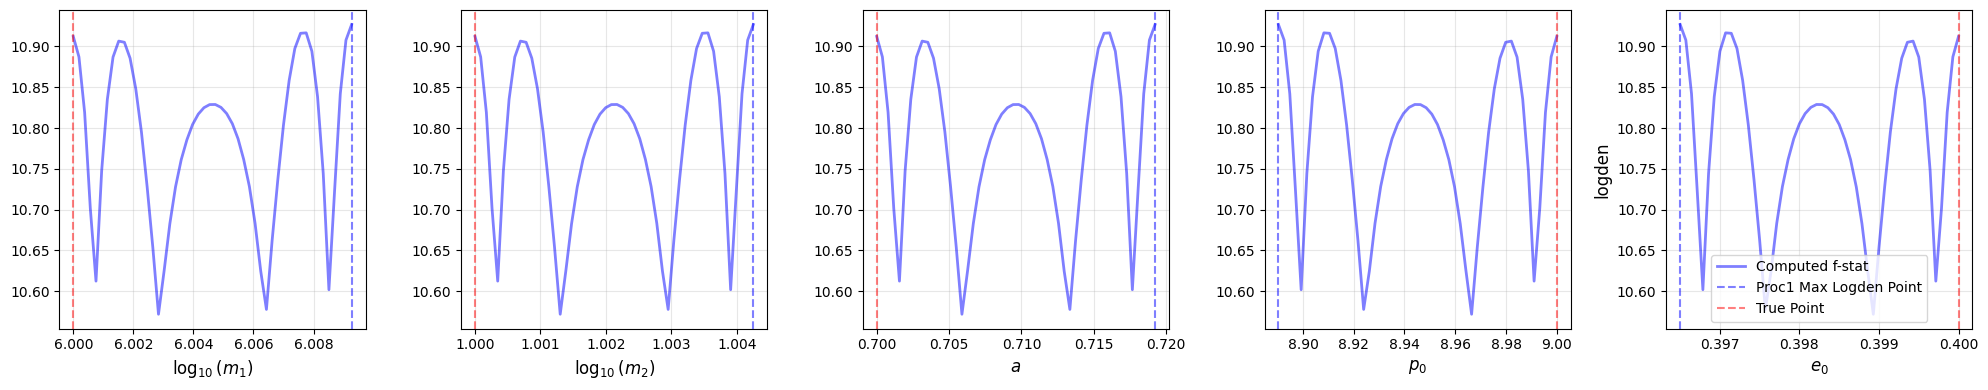

In [23]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$T$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [24]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [25]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [26]:
logden_tm = log_density(line_points_logm1.T)


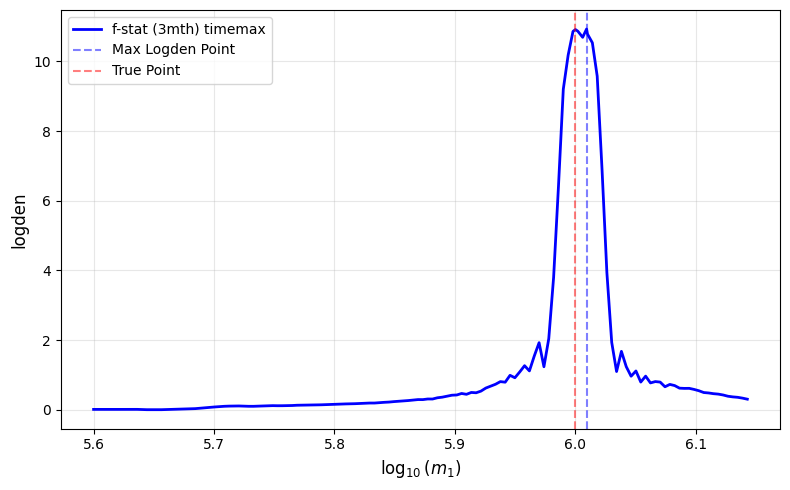

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='f-stat (3mth) timemax')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='Max Logden Point')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='True Point')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()